<a href="https://colab.research.google.com/github/Stamatics-NumberstoNeurons/assignment2-Prerana241/blob/main/Assignment_2_N2N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 - Numbers to Neurons

---
> Complete each question below. Write theory answers in Markdown cells and code in code cells.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---
## Q1 - Perceptrons and Sigmoid Neurons

### Q1a - NAND Perceptron

Write a Python class using NumPy that implements a **NAND logic gate** using a single perceptron. Your implementation must use **vectorized operations** (no explicit `for` loops in the activation function) to process an input matrix of shape `(N, 2)` and return the corresponding binary outputs.

Mathematically determine and set the correct weights and bias within your code.

In [24]:
#code here
class NANDPerceptron:

    def __init__(self):
        self.w = np.array([-1., -1.])
        self.b = 1.5

    def predict(self, X):
        return ((X @ self.w + self.b) >= 0).astype(int)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

nand = NANDPerceptron()
print(nand.predict(X))

[1 1 1 0]


### Q1b - Perceptron Sensitivity

Explain precisely why a tiny change in one weight can cause **chaos** in a perceptron network. What property of the perceptron makes this happen?

> **Your answer:**
A perceptron computes:

z = w·x + b

and then applies a step function:

output = 1 if z ≥ 0
output = 0 if z < 0

The step function is discontinuous. There is a sharp jump at:

z = 0

This means that if an input is close to the decision boundary, a very tiny change in a weight can move z from slightly negative to slightly positive (or vice versa).

### Q1c - Sigmoid to Perceptron Limit

Suppose you multiply all the weights and bias of a sigmoid neuron by a positive constant c > 0.

1. As c approaches what value will this sigmoid neuron behave exactly like a classic perceptron? Why mathematically?
2. Explain in 2-3 lines why we prefer sigmoid neurons over perceptrons.

> **Your answer:**
1. As:

c → ∞

the sigmoid neuron approaches a perceptron.

The sigmoid output is:

output = 1 / (1 + exp(-c(w·x + b)))

When c becomes very large:

If (w·x + b) > 0, then output → 1
If (w·x + b) < 0, then output → 0

Therefore the sigmoid becomes a step function:

output = 1 if (w·x + b) ≥ 0
output = 0 if (w·x + b) < 0

which is exactly the behaviour of a classic perceptron.

2. Sigmoid neurons are preferred because their output changes smoothly with changes in the weights and inputs.

The sigmoid function is differentiable, so gradients can be computed and gradient descent/backpropagation can be used for learning. Perceptrons use a hard step function, which is not differentiable and therefore cannot be trained efficiently using gradient-based methods.

---
## Q2 - The Quadratic Cost Function

$$C(w,b) = \frac{1}{2n} \sum_x \|y(x) - a\|^2$$

### Q2a - The Factor of 1/2

Why is there a factor of 1/2 in front? Derive why it is mathematically convenient when computing the derivative of C with respect to any weight w.

> **Your answer:**
When we differentiate with respect to a weight w, we use the chain rule.

The derivative of the squared term is:

d[(y-a)^2]/dw = 2(y-a) * d(y-a)/dw

The factor 2 appears because of the power rule.

However, since the cost function contains a factor of 1/2:

C = (1/2)(y-a)^2

the derivative becomes:

dC/dw
= (1/2) * 2(y-a) * d(y-a)/dw
= (y-a) * d(y-a)/dw

The 1/2 and 2 cancel exactly.

For the full cost function:

C(w,b) = (1/2n) Σ (y(x) - a)^2

the derivative is:

dC/dw
= (1/n) Σ (y(x) - a) * d(y(x))/dw

instead of:

dC/dw
= (2/n) Σ (y(x) - a) * d(y(x))/dw

if the 1/2 were absent.

### Q2b - Computing C by Hand

A network has two training examples:
- Example 1: output = 0.9, target = 1.0
- Example 2: output = 0.3, target = 0.0

Compute C by hand and explain what the value tells you about network performance.

> **Your answer:**
Here:

n = 2

For Example 1:

(target - output)^2
= (1.0 - 0.9)^2
= 0.1^2
= 0.01

For Example 2:

(target - output)^2
= (0.0 - 0.3)^2
= (-0.3)^2
= 0.09

Total squared error:

0.01 + 0.09 = 0.10

Therefore:

C = (1/(2×2))(0.10)
  = 0.025

So:

C = 0.025

This is a small cost, which means the network predictions are fairly close to the target values. A perfect network would have:

C = 0

because every output would exactly match its target.

In [20]:
# Verify your hand computation
outputs = np.array([0.9, 0.3])
targets = np.array([1.0, 0.0])

C_val = np.sum((targets - outputs)**2) / (2 * len(outputs)) # TODO: compute C
print(f'C = {C_val}')

C = 0.024999999999999998


### Q2c - Cost vs Accuracy

Explain why we use a cost function and do **not** directly maximise classification accuracy.

> **Your answer:**
Classification accuracy tells us only whether a prediction is correct or incorrect.

For example:

Prediction = 0.51, Target = 1  → Correct
Prediction = 0.99, Target = 1  → Correct

Both have the same accuracy, even though the second prediction is much better and more confident.

A cost function measures how wrong the predictions are, not just whether they are right or wrong.

For example:

Prediction = 0.49, Target = 1
Prediction = 0.01, Target = 1

Both are classified as incorrect, so they contribute the same amount to accuracy. However, the second prediction is much worse and should be penalized more heavily. A cost function captures this difference.

Another reason is that accuracy is not differentiable. Small changes in the weights often do not change the predicted class, so the accuracy remains constant and provides no useful gradient information.

Gradient descent requires derivatives to update the weights:

Weight update ∝ - d(Cost)/d(weight)

A smooth cost function provides meaningful gradients, allowing the network to learn.

### Q2d - Absolute Error vs Squared Error

An alternative cost is the absolute error: C = (1/n) * sum |y(x) - a|.

Explain **one mathematical problem** with using absolute error instead of squared error, specifically when doing gradient descent.

> **Your answer:**
A key mathematical problem with absolute error is that it is not differentiable at zero.

For absolute error:

C = (1/n) * Σ |y(x) - a|

the derivative of the absolute value function is:

d|x|/dx = 1   if x > 0
d|x|/dx = -1  if x < 0

but at:

x = 0

the derivative is undefined.

This creates a problem for gradient descent because gradient descent requires a well-defined derivative at every point in order to compute weight updates.

In contrast, squared error:

C = (1/2n) * Σ (y(x) - a)^2

is smooth and differentiable everywhere, including when the error is zero.

---
## Q3 - Gradient Descent on a Toy Cost Function

$$C(w, b) = (w - 3)^2 + 2(b - 1)^2$$

### Q3a - Minimum by Inspection

By inspection, what values of w and b minimise C? What is the minimum value of C? Explain your reasoning without calculus.

> **Your answer:**
A square is always non-negative:

(w - 3)^2 ≥ 0
(b - 1)^2 ≥ 0

Therefore:

C(w, b) ≥ 0

The minimum possible value occurs when both squared terms are exactly zero.

This happens when:

w - 3 = 0  ⇒  w = 3
b - 1 = 0  ⇒  b = 1

Substituting:

C(3,1) = (3-3)^2 + 2(1-1)^2
       = 0 + 0
       = 0

Hence:

w = 3
b = 1

minimise the cost function, and the minimum value of the cost is:

C = 0

No calculus is needed because the cost function is the sum of squared terms, and squares are smallest when they are zero.

### Q3b - Two Steps by Hand

Compute dC/dw and dC/db. Starting from (w, b) = (0, 0) with learning rate eta = 0.1, show the first two gradient descent update steps by hand. Where does the parameter vector end up after step 2?

> **Your answer:**
The gradients are:

dC/dw = 2(w-3)
dC/db = 4(b-1)

Start at:

w = 0, b = 0, eta = 0.1
Step 1

Gradients:

dC/dw = 2(0-3) = -6
dC/db = 4(0-1) = -4

Update:

w = 0 - 0.1(-6) = 0.6
b = 0 - 0.1(-4) = 0.4

Cost:

C(0.6,0.4) = (0.6-3)^2 + 2(0.4-1)^2
           = 5.76 + 0.72
           = 6.48
Step 2

Gradients at (0.6,0.4):

dC/dw = 2(0.6-3) = -4.8
dC/db = 4(0.4-1) = -2.4

Update:

w = 0.6 - 0.1(-4.8) = 1.08
b = 0.4 - 0.1(-2.4) = 0.64

Cost:

C(1.08,0.64) = (1.08-3)^2 + 2(0.64-1)^2
             = 3.6864 + 0.2592
             = 3.9456

After step 2, the parameter vector is:

(w,b) = (1.08, 0.64)

In [18]:
def cost(w, b):
    return (w - 3)**2 + 2*(b - 1)**2

def grad_cost(w, b):
    dw = 2*(w - 3)  # TODO
    db = 4*(b - 1)  # TODO
    return dw, db

# Verify your hand calculation
eta = 0.1
w, b = 0.0, 0.0
for step in range(1, 3):
    dw, db = grad_cost(w, b)
    w = w - eta * dw
    b = b - eta * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=0.6000, b=0.4000, C=6.4800
Step 2: w=1.0800, b=0.6400, C=3.9456


### Q3c - Too-Large Learning Rate

If you set eta = 0.6, what goes wrong on the b update? Show numerically. What does this tell you about learning rate selection?

> **Your answer:**
The gradients are:

dC/dw = 2(w-3)
dC/db = 4(b-1)

Notice that the gradient for b is multiplied by 4, making updates in the b direction larger than those in the w direction.

Starting from:

w = 0, b = 0, eta = 0.6

For b:

gradient = 4(0-1) = -4

Update:

b_new = 0 - 0.6(-4)
      = 2.4

The optimum value is:

b = 1

but after just one step:

b = 2.4

which has jumped past the optimum by a large amount.

Next step:

gradient = 4(2.4-1)
         = 5.6

Update:

b_new = 2.4 - 0.6(5.6)
      = -0.96

Now it jumps to the other side of the optimum.

So the sequence is:

0  →  2.4  →  -0.96  →  3.744  →  ...

The updates oscillate around the optimum and grow rather than settling down.

In [19]:
eta_bad = 0.6
w, b = 0.0, 0.0
for step in range(1, 5):
    dw, db = grad_cost(w, b)
    w = w - eta_bad * dw
    b = b - eta_bad * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=3.6000, b=2.4000, C=4.2800
Step 2: w=2.8800, b=-0.9600, C=7.6976
Step 3: w=3.0240, b=3.7440, C=15.0596
Step 4: w=2.9952, b=-2.8416, C=29.5158


---
## Q4 - Sigmoid Neuron: Implementation and Visualisation

In [14]:
class SigmoidNeuron:

    def __init__(self, weights, bias):
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)

    def forward(self, x):
        # TODO: compute z = w.x + b, return sigmoid(z)
         z = np.dot(self.weights, x) + self.bias
         return 1/(1 + np.exp(-z))


    def numerical_gradient(self, x, h=1e-5):
        # TODO: centered difference (f(x+h) - f(x-h)) / 2h
        gw = np.zeros_like(self.weights)

        for i in range(len(self.weights)):
            self.weights[i] += h
            fp = self.forward(x)
            self.weights[i] -= 2*h
            fm = self.forward(x)
            self.weights[i] += h
            gw[i] = (fp - fm)/(2*h)

        self.bias += h
        fp = self.forward(x)
        self.bias -= 2*h
        fm = self.forward(x)
        self.bias += h
        gb = (fp - fm)/(2*h)

        # return (grad_weights, grad_bias)
        return (gw, gb)


### Q4a - Forward Pass and Gradients

For weights=[2, -1] and bias=0.5, compute the output and all gradients at x=[1, 1]. Explain what the gradient w.r.t. w1 means in plain English.

In [15]:
neuron = SigmoidNeuron(weights=[2, -1], bias=0.5)
x = np.array([1.0, 1.0])

output = neuron.forward(x)
grad_w, grad_b = neuron.numerical_gradient(x)

print(f'Output:        {output}')
print(f'd(output)/dw1: {grad_w[0]:.6f}')
print(f'd(output)/dw2: {grad_w[1]:.6f}')
print(f'd(output)/db:  {grad_b:.6f}')

Output:        0.8175744761936437
d(output)/dw1: 0.149146
d(output)/dw2: 0.149146
d(output)/db:  0.149146


**Explanation of gradient w.r.t. w1:**

> **Your answer:**
The neuron first computes:

z = w1*x1 + w2*x2 + b

Substituting the values:

z = 2*1 + (-1)*1 + 0.5
  = 2 - 1 + 0.5
  = 1.5

The neuron output is the sigmoid of z:

output = 1 / (1 + exp(-1.5))
       ≈ 0.817574

Because:

x1 = 1
x2 = 1

The gradient with respect to a weight is proportional to the corresponding input.

Since both inputs are equal to 1:

d(output)/dw1 = d(output)/dw2

The gradient:

d(output)/dw1 ≈ 0.149146

means:

If we increase w1 by a tiny amount, the neuron's output will increase by about 0.149 times that amount.

For example, if:

w1 increases by 0.01

then the output will increase by approximately:

0.149146 × 0.01
≈ 0.00149

So w1 has a positive effect on the output, and the gradient tells us how sensitive the output is to changes in w1.

### Q4b - Plot sigma(z) and sigma'(z)

Plot sigma(z) and its derivative sigma'(z) = sigma(z)(1 - sigma(z)) for z in [-10, 10].

- At what value of z is the gradient largest?
- What happens as z approaches +/- infinity and why is this a problem (vanishing gradient)?

> **Your answer:**
The gradient is largest at:

z = 0

because:

sigma(0) = 0.5
sigma'(0) = 0.5 * (1 - 0.5) = 0.25

and 0.25 is the maximum value of the sigmoid derivative.

As:

z → +∞
sigma(z) → 1
sigma'(z) → 0

As:

z → -∞
sigma(z) → 0
sigma'(z) → 0

So the derivative becomes extremely small at both ends.

During backpropagation, weight updates depend on the gradient.

When:

sigma'(z) ≈ 0

the gradients become tiny, causing:

weight update ≈ 0

As a result, learning becomes extremely slow or may effectively stop in deep neural networks. This phenomenon is called the vanishing gradient problem.


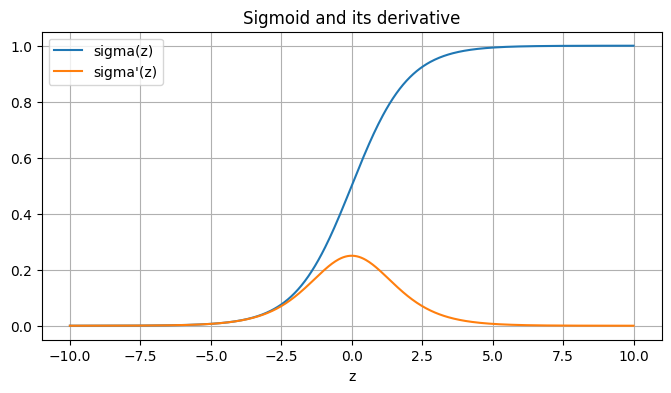

In [16]:
z = np.linspace(-10, 10, 500)

# TODO: compute sigma and sigma_prime
sigma       = 1/(1 + np.exp(-z))
sigma_prime = sigma*(1 - sigma)

plt.figure(figsize=(8, 4))
# TODO: plot both curves
plt.plot(z, sigma, label='sigma(z)')
plt.plot(z, sigma_prime, label="sigma'(z)")
plt.xlabel('z')
plt.legend()
plt.title('Sigmoid and its derivative')
plt.grid(True)
plt.show()

### Q4c - Is sigma(100z) basically a perceptron?

A classmate claims: 'a sigmoid neuron with weights multiplied by 100 is basically the same as a perceptron.'

Plot sigma(100z) vs sigma(z) vs the step function. Is the claim correct? Under what condition does it break down?

> **Your answer:**
sigma(z) is a smooth S-shaped curve.
sigma(100z) becomes extremely steep around z = 0.
It closely resembles the perceptron step function:
output ≈ 0 for z < 0
output ≈ 1 for z > 0

Therefore, a sigmoid neuron with very large weights behaves almost like a perceptron.

The claim breaks down near the decision boundary:

z ≈ 0

because:

A perceptron has a discontinuous jump from 0 to 1.
sigma(100z) is still continuous and differentiable.
Its output can take intermediate values near z = 0.

It also breaks down during training because a perceptron has no useful gradient, whereas the sigmoid neuron remains differentiable (although for very large weights its gradients vanish almost everywhere).

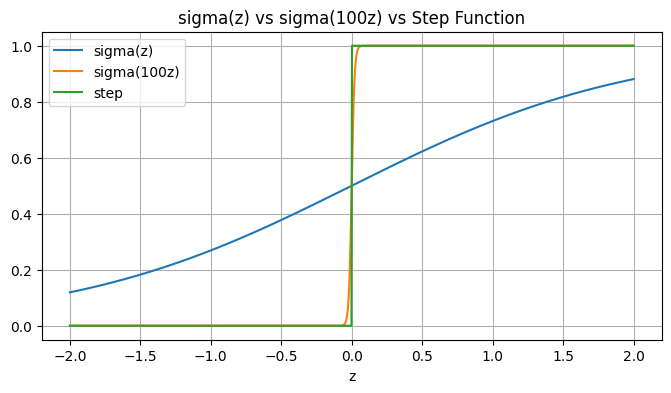

In [17]:
z = np.linspace(-2, 2, 1000)

# TODO: compute sigma(z), sigma(100*z), step function
sigma = 1/(1 + np.exp(-z))
sigma100 = 1/(1 + np.exp(-100*z))
step = (z >= 0).astype(int)

plt.figure(figsize=(8, 4))
# TODO: plot all three
plt.plot(z, sigma, label='sigma(z)')
plt.plot(z, sigma100, label='sigma(100z)')
plt.plot(z, step, label='step')
plt.title('sigma(z) vs sigma(100z) vs Step Function')
plt.xlabel('z')
plt.legend()
plt.grid(True)
plt.show()

---
## Q5 - Gradient Descent on a Toy Regression Problem

A single-layer network (one input, one output, no activation) must learn y = 3x + 1.

In [6]:
X_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

### Q5a - Analytical Gradients + Full-Batch GD

Derive dC/dw and dC/db analytically (show algebra). Implement full-batch GD with eta = 0.01 for 200 epochs. Plot the loss curve. Do w and b converge to 3 and 1?

**Derivation (show algebra):**

> **Your answer:**
Say the network predicts, y_hat_i = wx_i + b
Thus Mean Squared Error(MSE) Cost functon C = 1/(2N) * sum from i=1 to N of (y_hat_i - y_i)^2 = 1/(2N) * sum from i=1 to N of (w * x_i + b - y_i)^2

del C/del w = 1/(2N) * sum from i=1 to N of 2 * (w * x_i + b - y_i) * d/dw(w * x_i + b - y_i)
=> del C/del w = 1/N * sum from i=1 to N of (w * x_i + b - y_i) * (x_i)
=> del C/del w = 1/N * sum from i=1 to N of (y_hat_i - y_i) * x_i

del C /del b = 1/(2N) * sum from i=1 to N of 2 * (w * x_i + b - y_i) * d/db(w * x_i + b - y_i)
=> del C/del b = 1/N * sum from i=1 to N of (w * x_i + b - y_i) * (1)
=> del C/del b = 1/N * sum from i=1 to N of (y_hat_i - y_i)

w and b get very close to 3 and 1 but don't exactly converge as eta = 0.01 is small.

Final w = 2.9951, b = 1.0141


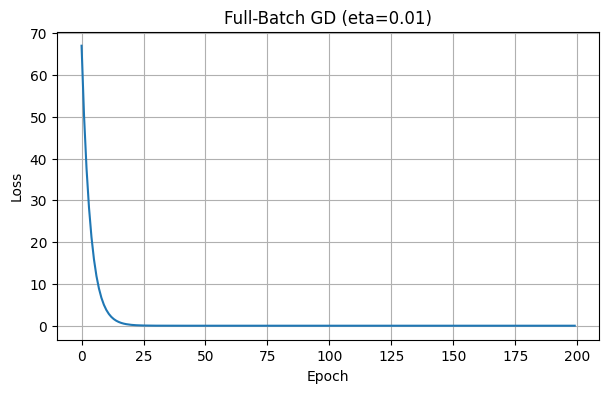

In [8]:
y = 3*x + 1
w, b = 0.0, 0.0
eta = 0.01
losses = []

for epoch in range(200):
    # TODO: predictions, loss, gradients, update
    y_pred = w * X_train + b
    loss = np.mean((y_pred - y_train)**2)

    dw = 2 * np.mean((y_pred - y_train) * X_train)
    db = 2 * np.mean(y_pred - y_train)

    w -= eta * dw
    b -= eta * db

    losses.append(loss)

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.01)')
plt.grid(True)
plt.show()

### Q5b - SGD with Mini-Batch Size = 1

Implement SGD with batch size 1. Train 200 epochs with eta = 0.01. Plot the loss curve. How does it differ from full-batch? Explain in terms of gradient quality and noise.

> **Your answer:**
1. Gradient Quality:
Full-Batch GD: Takes long to calculate the perfect average direction across all 100 points before taking a single step. It makes 1 parameter update per epoch.

SGD (Mini-Batch=1): Calculates an approximate gradient based on one data point, but it updates the weights 100 times per epoch (once for every point in the dataset). Because it takes so many steps per epoch, SGD converges much faster to the optimum.

2. Noise:
Full-Batch GD: The loss curve is smooth as it updates everything at once.
SGD (Mini-Batch = 1): The loss curve is chaotic and noisy as one point may not represent the whole landscape. Near the minimum there are small disturbances.

Final w = 3.0103, b = 0.9671


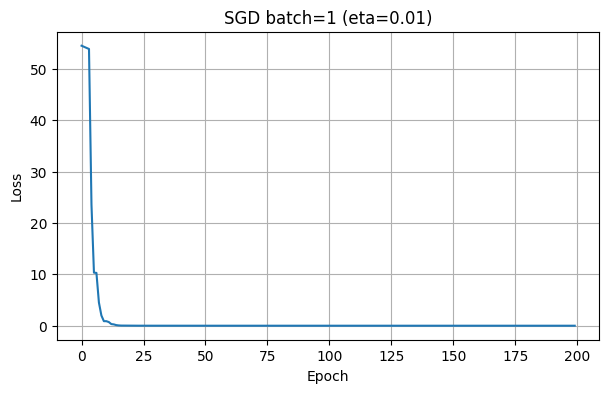

In [9]:
w, b = 0.0, 0.0
eta = 0.01
losses_sgd = []

for epoch in range(200):
    # TODO: pick random example, compute gradient, update
    i = np.random.randint(len(X_train))

    y_pred = w*X_train[i] + b
    err = y_pred - y_train[i]

    w -= eta * 2 * err * X_train[i]
    b -= eta * 2 * err
    loss = np.mean((w*X_train + b - y_train)**2)
    losses_sgd.append(loss)

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses_sgd)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SGD batch=1 (eta=0.01)')
plt.grid(True)
plt.show()

### Q5c - Divergence with eta = 0.5

Set eta = 0.5 with full-batch GD. Show the loss curve and explain using the gradient formulas from Q5a why it diverges.

> **Your answer:**
The gradient with respect to the weight is calculated as:
dw = 1/N * sum from i=1 to N of (y_hat_i - y_i) * x_i
As input features X are distributed between -2 and 2, many x_i data points have an absolute value greater than 1. When computing dw, the individual errors (y_hat_i - y_i) get multiplied by these x_i values. This scales up the magnitude of dw significantly compared to db.

When updating the weight, the new weight value is determined by:
w_new = w_old - eta * dwWith eta = 0.5
We are telling the network to shift its weight by half of the total gradient value. Because dw is already large due to the distribution of X, multiplying it by 0.5 creates a massive positional jump on the error curve.Instead of gently sliding down towards the minimum the step size is so violently large that w leaps completely over the valley and lands significantly higher up on the opposite hillside.

The prediction error (y_hat_i - y_i) for the next epoch becomes much larger than before. Because the error is larger, the gradient formulas (dw and db) yield exponentially larger values. In the next update, the step size (eta * dw) becomes even more colossal, throwing the model even further up the opposite side of the valley.

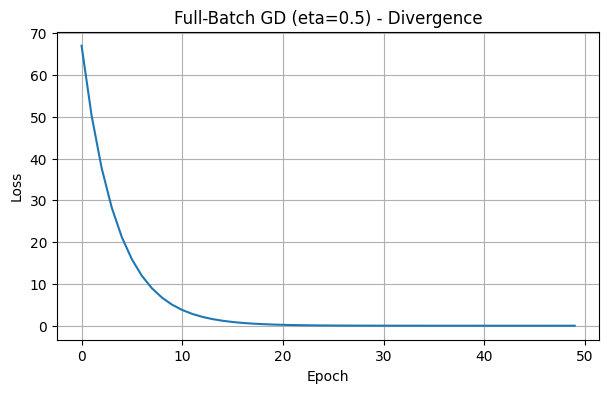

In [10]:
w, b = 0.0, 0.0
losses_div = []

for epoch in range(50):
    # TODO: full-batch GD with eta=0.5
    y_pred = w*X_train + b

    loss = np.mean((y_pred - y_train)**2)
    losses_div.append(loss)
    dw = 2*np.mean((y_pred - y_train)*X_train)
    db = 2*np.mean(y_pred - y_train)

    w -= eta*dw
    b -= eta*db
    if loss is not None and not np.isfinite(loss):
        print(f'Diverged at epoch {epoch}')
        break

plt.figure(figsize=(7, 4))
plt.plot(losses_div)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.5) - Divergence')
plt.grid(True)
plt.show()

---
## Q6 - One-Hot to 4-Bit Binary Encoding Layer

A network classifies digits 0-9 with a 10-neuron one-hot output. Design a final **4-neuron layer** that converts this into a **4-bit binary** encoding (e.g. digit 5 outputs 0101). Specify the weight matrix and bias vector.

**Design and Reasoning:**

> **Your answer:**
We use matrix multiplication here. When a matrix W of shape (4, 10) multiplies a one-hot vector x representing digit d(where x_d = 1 and all other entries are 0), the operation Wx extracts the d-th column of W.
1. The d-th column of W must directly correspond to the 4-bit binary string of digit d to extract that column.
2. As the threshold is 0.5 and the weight matrix already has 0s for the wrong digits and 1 foe the correct one, the bias vector can be 0 matrix.

In [5]:
# TODO: define W (4x10) and b_enc (4,)
W     = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1],  # shape (4, 10)
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 1, 1, 0, 0, 1, 1, 0, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
])
b_enc = np.zeros(4)  # shape (4,)

def threshold(x):
    return (x >= 0.5).astype(int)

print('Digit | Output | Expected | OK?')
print('-' * 35)
for digit in range(10):
    one_hot = np.zeros(10)
    one_hot[digit] = 1.0
    out = threshold(W @ one_hot + b_enc)
    expected = format(digit, '04b')
    ok = 'OK' if ''.join(map(str, out)) == expected else 'FAIL'
    print(f'  {digit}   |  {out}  |  {expected}  | {ok}')

Digit | Output | Expected | OK?
-----------------------------------
  0   |  [0 0 0 0]  |  0000  | OK
  1   |  [0 0 0 1]  |  0001  | OK
  2   |  [0 0 1 0]  |  0010  | OK
  3   |  [0 0 1 1]  |  0011  | OK
  4   |  [0 1 0 0]  |  0100  | OK
  5   |  [0 1 0 1]  |  0101  | OK
  6   |  [0 1 1 0]  |  0110  | OK
  7   |  [0 1 1 1]  |  0111  | OK
  8   |  [1 0 0 0]  |  1000  | OK
  9   |  [1 0 0 1]  |  1001  | OK


---
## Q7 - Geometric Interpretation of 1D Gradient Descent

Consider C(v) as a function of a single scalar v.

1. Give a precise **geometric interpretation** of the update rule v = v - alpha * dC/dv.
2. How do the slope and the learning rate alpha physically dictate movement along the curve?

> **Your answer:**
1. The update rule is Gradient Descent in 1D. -dC/dv represents the negative of the slope of the tangent line to the curve C(v) at the point v. It points in the direction of steepest descent. The update helps move v towards its minimum or optimum value.

2. Slope:
Steep Regions: When v is far from the minimum, |dC/dV| is large. This causes the algorithm to take larger steps, rapidly moving towards minimum.
Flat Regions: As v approaches a local minimum, the tangent flattens and |dC/dv| approaches 0. This forces the algorithm to take smaller to avoid overshooting.

Learning rate:
Too small: The model learns very slowly, is inefficient and takes a long time to reach optimum.
Too large: The model takes large steps, may lead to oscillations and overshoot; is not stable.
Well-tuned: The model efficiently reaches optimum at a steady rate.


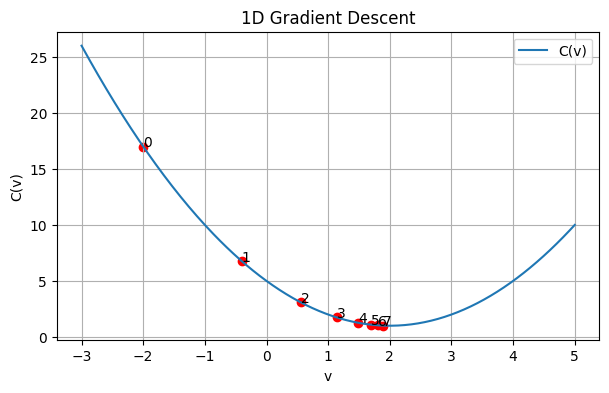

In [4]:
v_vals = np.linspace(-3, 5, 300)
C_v = (v_vals - 2)**2 + 1

# TODO: run gradient descent steps and annotate on the curve
v, alpha = -2, 0.2
pts = []

for _ in range(8):
    pts.append((v, (v-2)**2 + 1))
    v -= alpha * 2*(v-2)
plt.figure(figsize=(7, 4))
plt.plot(v_vals, C_v, label='C(v)')
plt.scatter(*zip(*pts), c='r')
for i,(x,y) in enumerate(pts):
    plt.annotate(i,(x,y))
plt.xlabel('v')
plt.ylabel('C(v)')
plt.title('1D Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

---
## Q8 - Zero Hidden Layers: What Model Are You Really Training?

Suppose you remove all hidden layers, connecting 784 inputs directly to 10 outputs, trained with SGD.

1. What **mathematical model** have you effectively created?
2. Why is classification accuracy **fundamentally capped**?
3. What does this imply about the **necessity of hidden layers**?

> **Your answer:**
1. The mathematical model created is a ingle-layer perceptron with a softmax activation function. As there are no hidden layers to learn intermediate representations, each of the 10 outputs is only a weighted linear combination of the 784 input pixels plus a bias term, passed through the Softmax activation function for multi-class classification.
y_j = softmax( sum from i=1 to 784 of (w_ji * x_i) + b_j )

2. The accuracy of this model is strictly limited because a single-layer network can only learn linear decision boundaries. The model tries to separate the 10 classes using hyperplanes in a 784-dimensional space. But most real world data is non linear and linear classification fails in such cases.

3. Hidden layers (with non-linear activation functions like ReLU or sigmoid) change the input space so that the final output data is still linearly separable.

Hidden layers allow the network to build a hierarchy of features:

Hidden Layer 1 may detect simple edges and lines.

Hidden Layer 2 may combine those lines into shapes and loops.

Output layer combines those into distinct digit shapes.